# 07 — SHAP Feature Importance: Top 3 Models per Type

Compute SHAP values for the top 3 performing variants (by test RMSE) of each model type.
This reveals which features drive predictions and how they interact.

| Model | Variant 1 | Variant 2 | Variant 3 |
|-------|-----------|-----------|----------|
| A (lap+tyre) | LightGBM_Shallow | LightGBM_Deep | LightGBM |
| B (lap-notyre) | LightGBM_DART | LightGBM | LightGBM_Deep |
| C (race-level) | RandomForest | ExtraTrees | LightGBM_Shallow |
| D (stacking) | XGBoost_shallow | LightGBM_shallow | RidgeCV |

## 0. Setup

In [1]:
import os
from pathlib import Path

if not (Path.cwd() / "pyproject.toml").exists():
    for p in [Path.cwd().parent, Path.cwd().parent.parent]:
        if (p / "pyproject.toml").exists():
            os.chdir(p)
            break

print(f"Working directory: {Path.cwd()}")

Working directory: C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor


In [2]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import shap

from f1_predictor.data.storage import load_from_gcs_or_local, sync_training_from_gcs
from f1_predictor.features.splits import LeaveOneSeasonOut, ExpandingWindowSplit

warnings.filterwarnings("ignore", category=UserWarning)
matplotlib.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

MODEL_DIR = Path("data/raw/model")
TRAINING_DIR = Path("data/training")

for mt in ["A", "B", "C", "D"]:
    sync_training_from_gcs(mt, TRAINING_DIR)
print("Synced training artifacts from GCS.")

Synced training artifacts from GCS.


In [3]:
TOP3 = {
    "A": ["LightGBM_Shallow", "LightGBM_Deep", "LightGBM"],
    "B": ["LightGBM_DART", "LightGBM", "LightGBM_Deep"],
    "C": ["RandomForest", "ExtraTrees", "LightGBM_Shallow"],
    "D": ["XGBoost_shallow", "LightGBM_shallow", "RidgeCV"],
}

FEATURE_COLS = {
    "A": [
        "gap_to_leader", "lap_time_delta_race_median", "gap_to_ahead",
        "position_change_from_lap1", "tire_life", "race_progress_pct",
        "degradation_rate", "compound_pace_delta", "pit_stop_count",
    ],
    "B": [
        "gap_to_leader", "lap_time_delta_race_median", "gap_to_ahead",
        "race_progress_pct", "position_change_from_lap1", "laps_since_last_pit",
        "pit_stop_count", "lap_time_rolling_3",
    ],
    "C": [
        "grid_position", "quali_delta_to_pole", "team_avg_finish_last_3",
        "best_quali_sec", "position_trend", "team_points_cumulative_season",
        "points_last_3", "weather_wind_max_kph", "driver_circuit_avg_finish",
        "weather_temp_max", "quali_position_vs_teammate", "dnf_rate_season",
        "circuit_avg_dnf_rate", "weather_precip_mm", "driver_circuit_races",
    ],
    "D": ["pred_A", "pred_B", "pred_C"],
}

DATA_PATHS = {
    "A": "data/processed/lap_tyre/features_laps_tyre.parquet",
    "B": "data/processed/lap_notyre/features_laps_notyre.parquet",
    "C": "data/processed/race/features_race.parquet",
}

TARGETS = {"A": "position", "B": "position", "C": "finish_position", "D": "finish_position"}

print("Configuration loaded.")

Configuration loaded.


## 1. Load Models and Reconstruct Test Sets

In [4]:
def load_model(model_type, variant):
    """Load a trained model pickle."""
    path = MODEL_DIR / f"Model_{model_type}_{variant}.pkl"
    with open(path, "rb") as f:
        return pickle.load(f)


def get_test_data_abc(model_type):
    """Load features and return test split for Models A/B/C."""
    df = load_from_gcs_or_local(
        DATA_PATHS[model_type],
        Path(DATA_PATHS[model_type]),
    )
    target = TARGETS[model_type]
    features = FEATURE_COLS[model_type]
    df = df.dropna(subset=[target]).reset_index(drop=True)

    X = df[features]
    y = df[target]
    groups = df["season"].values

    if model_type == "A":
        splitter = LeaveOneSeasonOut(test_season=2024)
    else:
        splitter = ExpandingWindowSplit(test_season=2025)

    _, test_idx = splitter.get_test_split(groups)
    return X.iloc[test_idx], y.iloc[test_idx]


def get_test_data_d():
    """Reconstruct Model D test set from OOF Validation parquets (season 2023)."""
    merge_key = ["season", "round", "driver_abbrev"]
    TEST_SEASON = 2023

    def load_val_preds(mt):
        best_variant = TOP3[mt][0]
        pq = TRAINING_DIR / f"model_{mt}_{best_variant}_Validation.parquet"
        df = pd.read_parquet(pq)
        if "lap_number" in df.columns:
            df = df.sort_values(merge_key + ["lap_number"])
            df = df.groupby(merge_key).tail(1)
        return df[df["season"] == TEST_SEASON]

    race_C = load_val_preds("C").rename(columns={"y_pred": "pred_C", "y_true": "true_C"})
    race_A = load_val_preds("A").rename(columns={"y_pred": "pred_A"})
    race_B = load_val_preds("B").rename(columns={"y_pred": "pred_B"})

    meta = race_C[merge_key + ["pred_C", "true_C"]].copy()
    meta = meta.merge(race_A[merge_key + ["pred_A"]], on=merge_key, how="left")
    meta = meta.merge(race_B[merge_key + ["pred_B"]], on=merge_key, how="left")
    meta["finish_position"] = meta["true_C"]
    meta = meta.dropna(subset=["finish_position", "pred_A", "pred_B", "pred_C"])

    X = meta[FEATURE_COLS["D"]]
    y = meta["finish_position"]
    return X, y


print("Helper functions defined.")

Helper functions defined.


## 2. Compute SHAP Values

For tree-based models (LightGBM, XGBoost, RandomForest, ExtraTrees) we use `TreeExplainer`.
For linear models (RidgeCV) we use `LinearExplainer`.

In [5]:
shap_results = {}

for model_type in ["A", "B", "C", "D"]:
    print(f"\n{'='*60}")
    print(f"Model {model_type}")
    print(f"{'='*60}")

    if model_type == "D":
        X_test, y_test = get_test_data_d()
    else:
        X_test, y_test = get_test_data_abc(model_type)

    print(f"  Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")

    for variant in TOP3[model_type]:
        print(f"  Computing SHAP for {variant}...", end=" ")
        model = load_model(model_type, variant)

        # Sample for large datasets (lap-level models)
        if len(X_test) > 1000:
            X_shap = X_test.sample(n=1000, random_state=42)
        else:
            X_shap = X_test.copy()

        # Handle pipeline wrappers (Model D RidgeCV uses SimpleImputer + model)
        actual_model = model
        X_explain = X_shap
        if hasattr(model, "named_steps"):
            # sklearn Pipeline: transform first, explain the final estimator
            from sklearn.pipeline import Pipeline
            steps = list(model.named_steps.keys())
            if len(steps) > 1:
                preprocessor = Pipeline(model.steps[:-1])
                X_explain = pd.DataFrame(
                    preprocessor.transform(X_shap),
                    columns=X_shap.columns,
                    index=X_shap.index,
                )
                actual_model = model.steps[-1][1]

        model_name = type(actual_model).__name__
        tree_models = (
            "LGBMRegressor", "XGBRegressor",
            "RandomForestRegressor", "ExtraTreesRegressor",
        )

        if model_name in tree_models:
            explainer = shap.TreeExplainer(actual_model)
            shap_values = explainer.shap_values(X_explain)
        elif model_name in ("RidgeCV", "Ridge", "Lasso", "ElasticNet"):
            explainer = shap.LinearExplainer(actual_model, X_explain)
            shap_values = explainer.shap_values(X_explain)
        else:
            explainer = shap.Explainer(actual_model, X_explain)
            shap_values = explainer(X_explain).values

        shap_results[(model_type, variant)] = {
            "shap_values": shap_values,
            "X": X_explain,
            "feature_names": list(X_explain.columns),
        }
        print(f"done ({X_explain.shape[0]} samples)")

print(f"\nComputed SHAP values for {len(shap_results)} model-variant combinations.")


Model A


GCS unavailable for data/processed/lap_tyre/features_laps_tyre.parquet, reading local: data\processed\lap_tyre\features_laps_tyre.parquet
Traceback (most recent call last):
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\src\f1_predictor\data\storage.py", line 93, in load_from_gcs_or_local
    df = read_parquet_from_gcs(gcs_blob)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\src\f1_predictor\data\storage.py", line 50, in read_parquet_from_gcs
    return pd.read_parquet(uri)
           ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\pandas\io\parquet.py", line 669, in read_parquet
    return impl.read(
           ^^^^^^^^^^
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\pandas\io\parquet.py", line 265, in read
    pa_table = s

  Test set: 26578 samples, 9 features
  Computing SHAP for LightGBM_Shallow... 

done (1000 samples)
  Computing SHAP for LightGBM_Deep... 

done (1000 samples)
  Computing SHAP for LightGBM... 

done (1000 samples)

Model B


GCS unavailable for data/processed/lap_notyre/features_laps_notyre.parquet, reading local: data\processed\lap_notyre\features_laps_notyre.parquet
Traceback (most recent call last):
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\src\f1_predictor\data\storage.py", line 93, in load_from_gcs_or_local
    df = read_parquet_from_gcs(gcs_blob)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\src\f1_predictor\data\storage.py", line 50, in read_parquet_from_gcs
    return pd.read_parquet(uri)
           ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\pandas\io\parquet.py", line 669, in read_parquet
    return impl.read(
           ^^^^^^^^^^
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\pandas\io\parquet.py", line 265, in read
    pa_t

  Test set: 2400 samples, 8 features
  Computing SHAP for LightGBM_DART... 

done (1000 samples)
  Computing SHAP for LightGBM... 

done (1000 samples)
  Computing SHAP for LightGBM_Deep... 

done (1000 samples)

Model C


GCS unavailable for data/processed/race/features_race.parquet, reading local: data\processed\race\features_race.parquet
Traceback (most recent call last):
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\src\f1_predictor\data\storage.py", line 93, in load_from_gcs_or_local
    df = read_parquet_from_gcs(gcs_blob)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\src\f1_predictor\data\storage.py", line 50, in read_parquet_from_gcs
    return pd.read_parquet(uri)
           ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\pandas\io\parquet.py", line 669, in read_parquet
    return impl.read(
           ^^^^^^^^^^
  File "C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\pandas\io\parquet.py", line 265, in read
    pa_table = self.api.parquet.re

  Test set: 479 samples, 15 features
  Computing SHAP for RandomForest... 

done (479 samples)
  Computing SHAP for ExtraTrees... 

done (479 samples)
  Computing SHAP for LightGBM_Shallow... 

done (479 samples)

Model D
  Test set: 430 samples, 3 features
  Computing SHAP for XGBoost_shallow... 

done (430 samples)
  Computing SHAP for LightGBM_shallow... done (430 samples)
  Computing SHAP for RidgeCV... done (430 samples)

Computed SHAP values for 12 model-variant combinations.


## 3. SHAP Summary Plots (Top 3 per Model Type)

Each row shows the three best-performing variants of a model type.
The beeswarm plot shows feature importance and direction of effect.

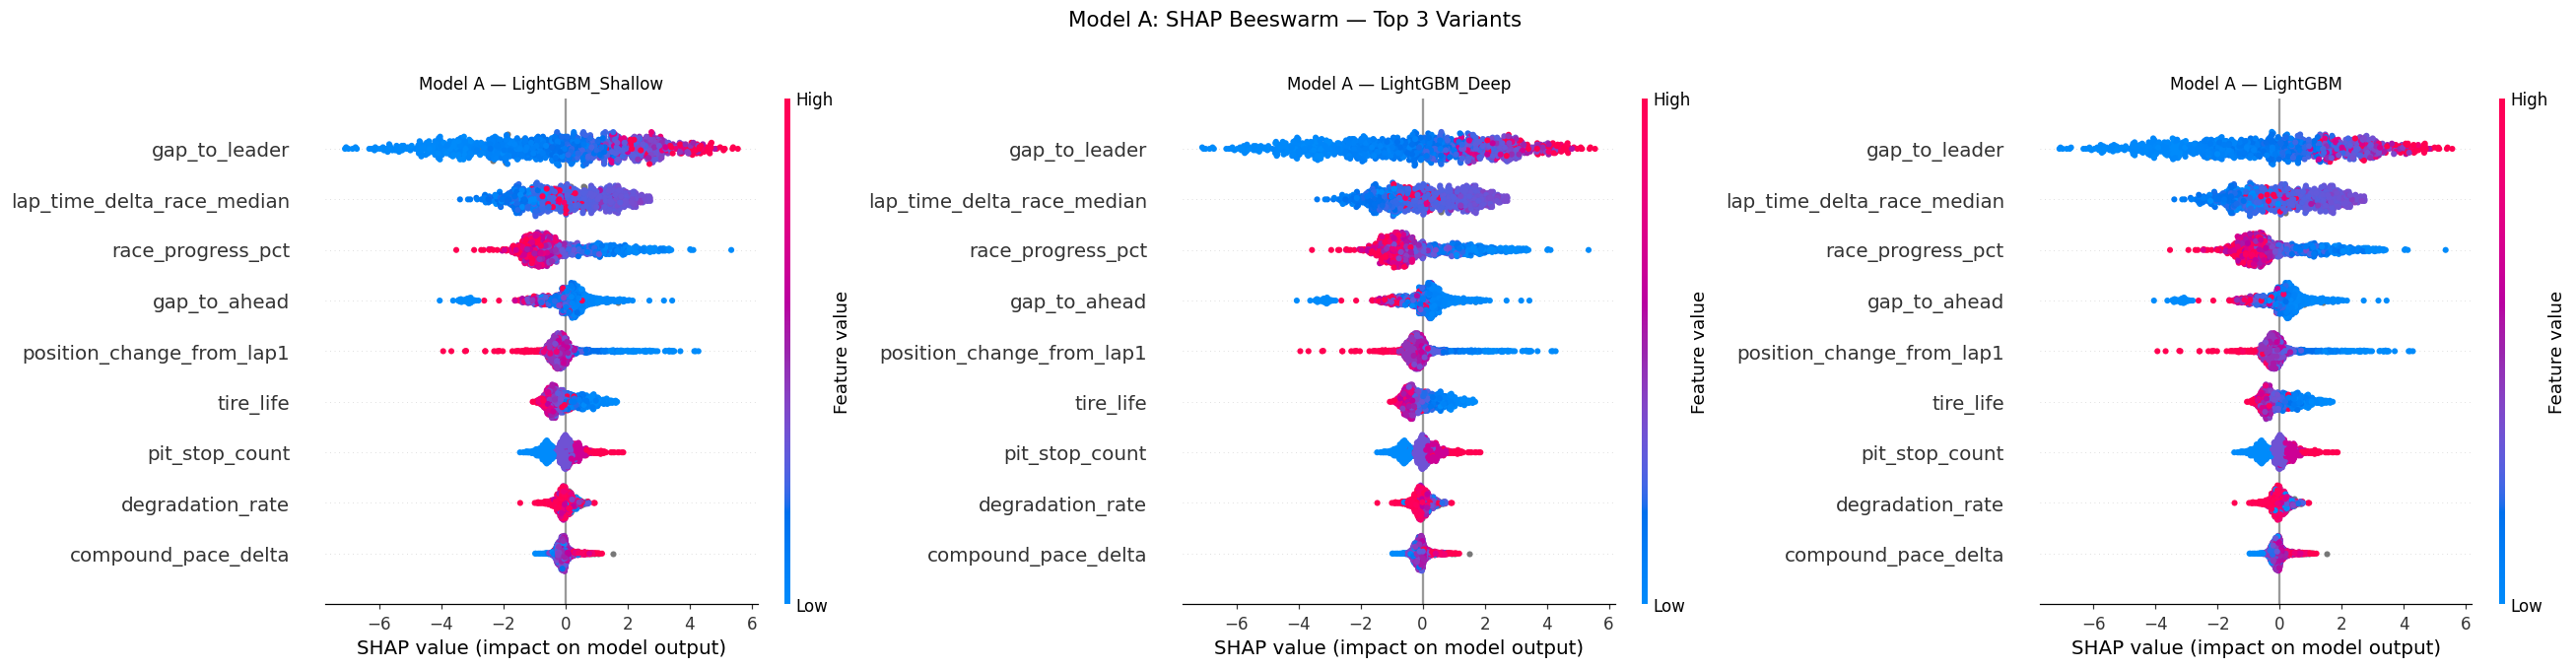

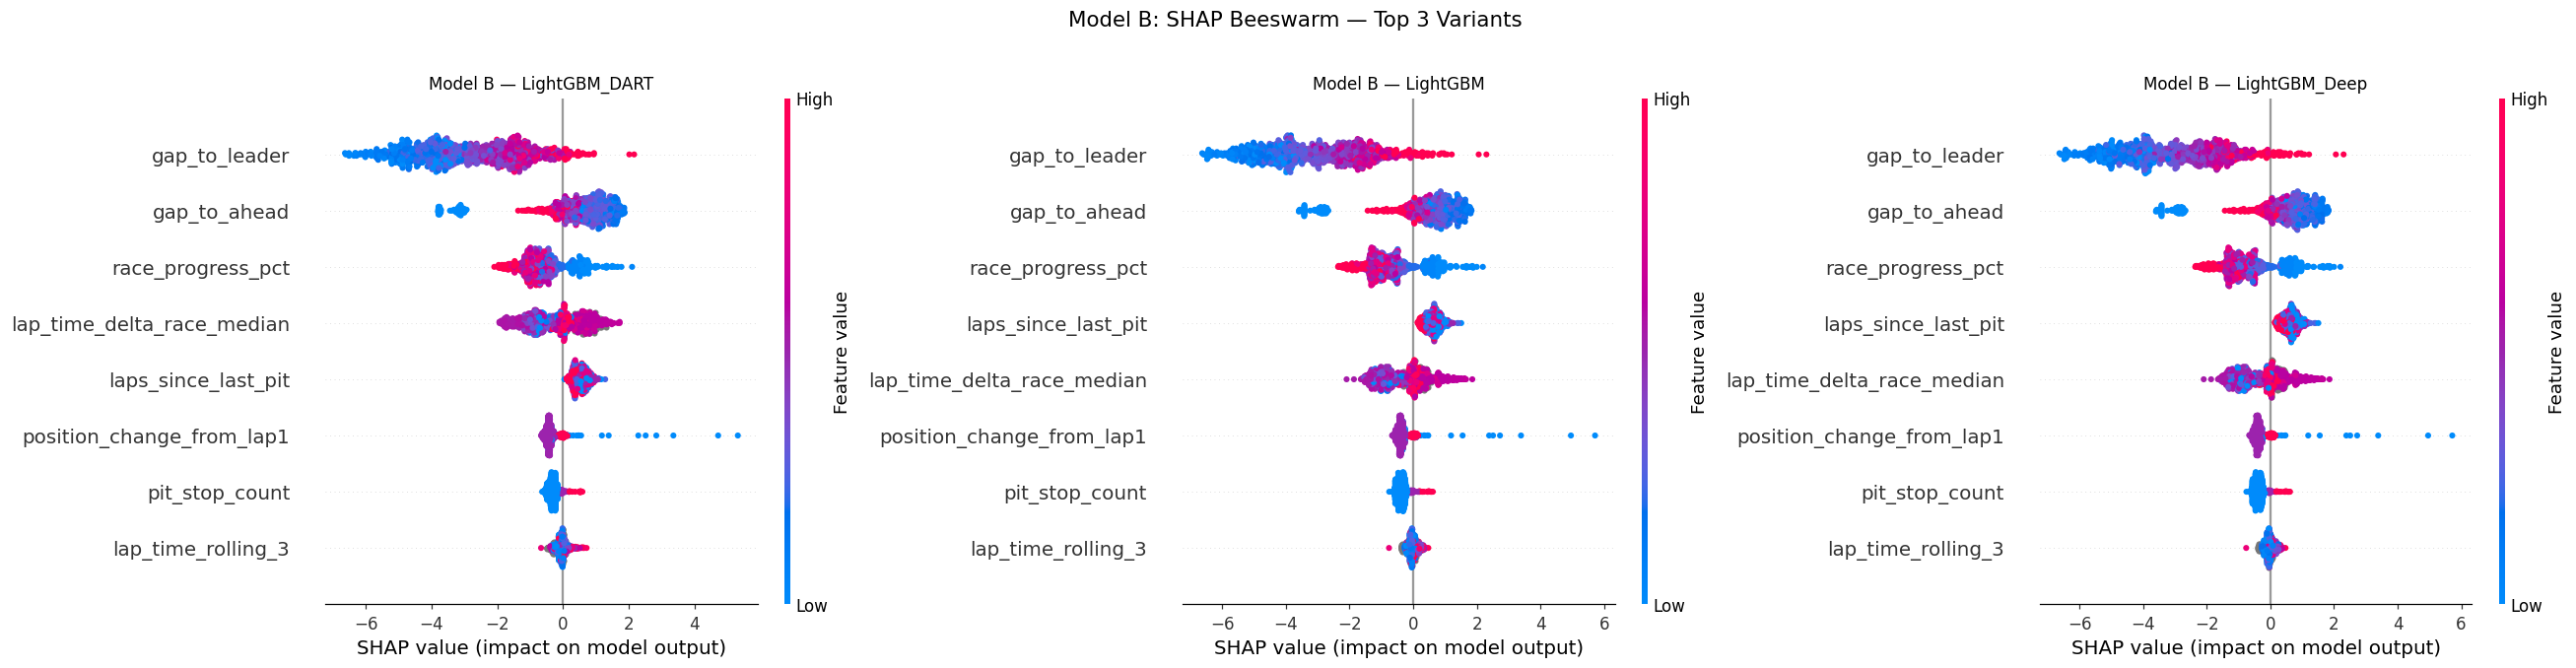

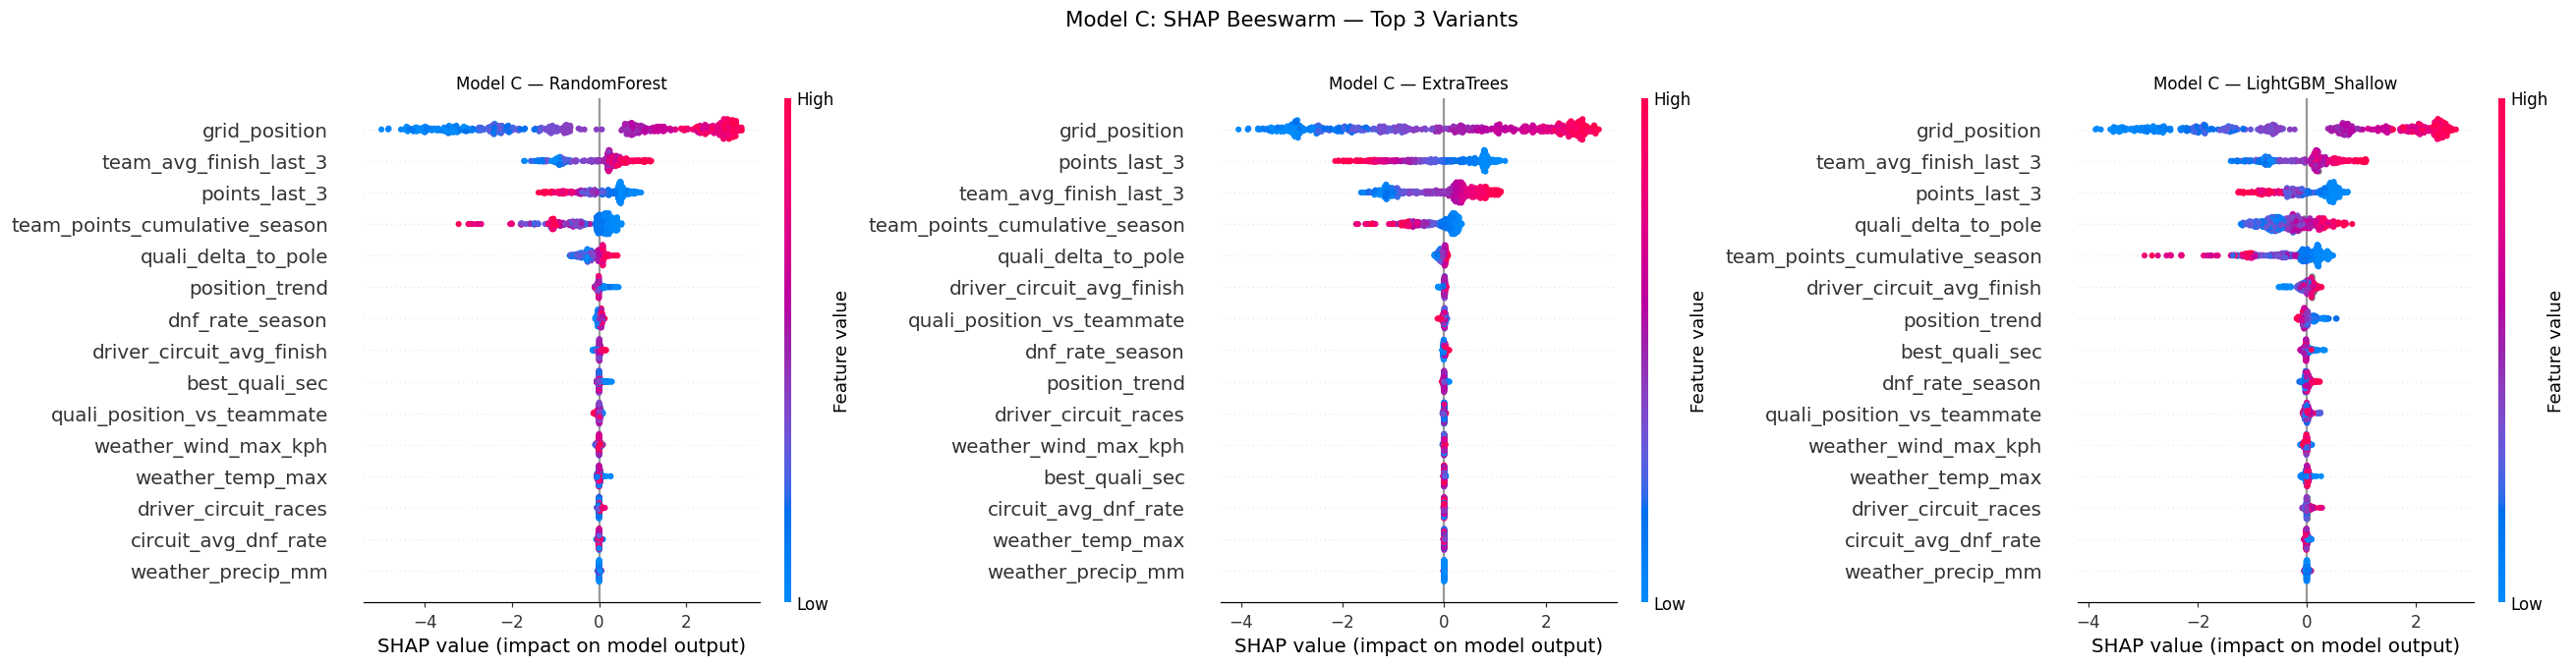

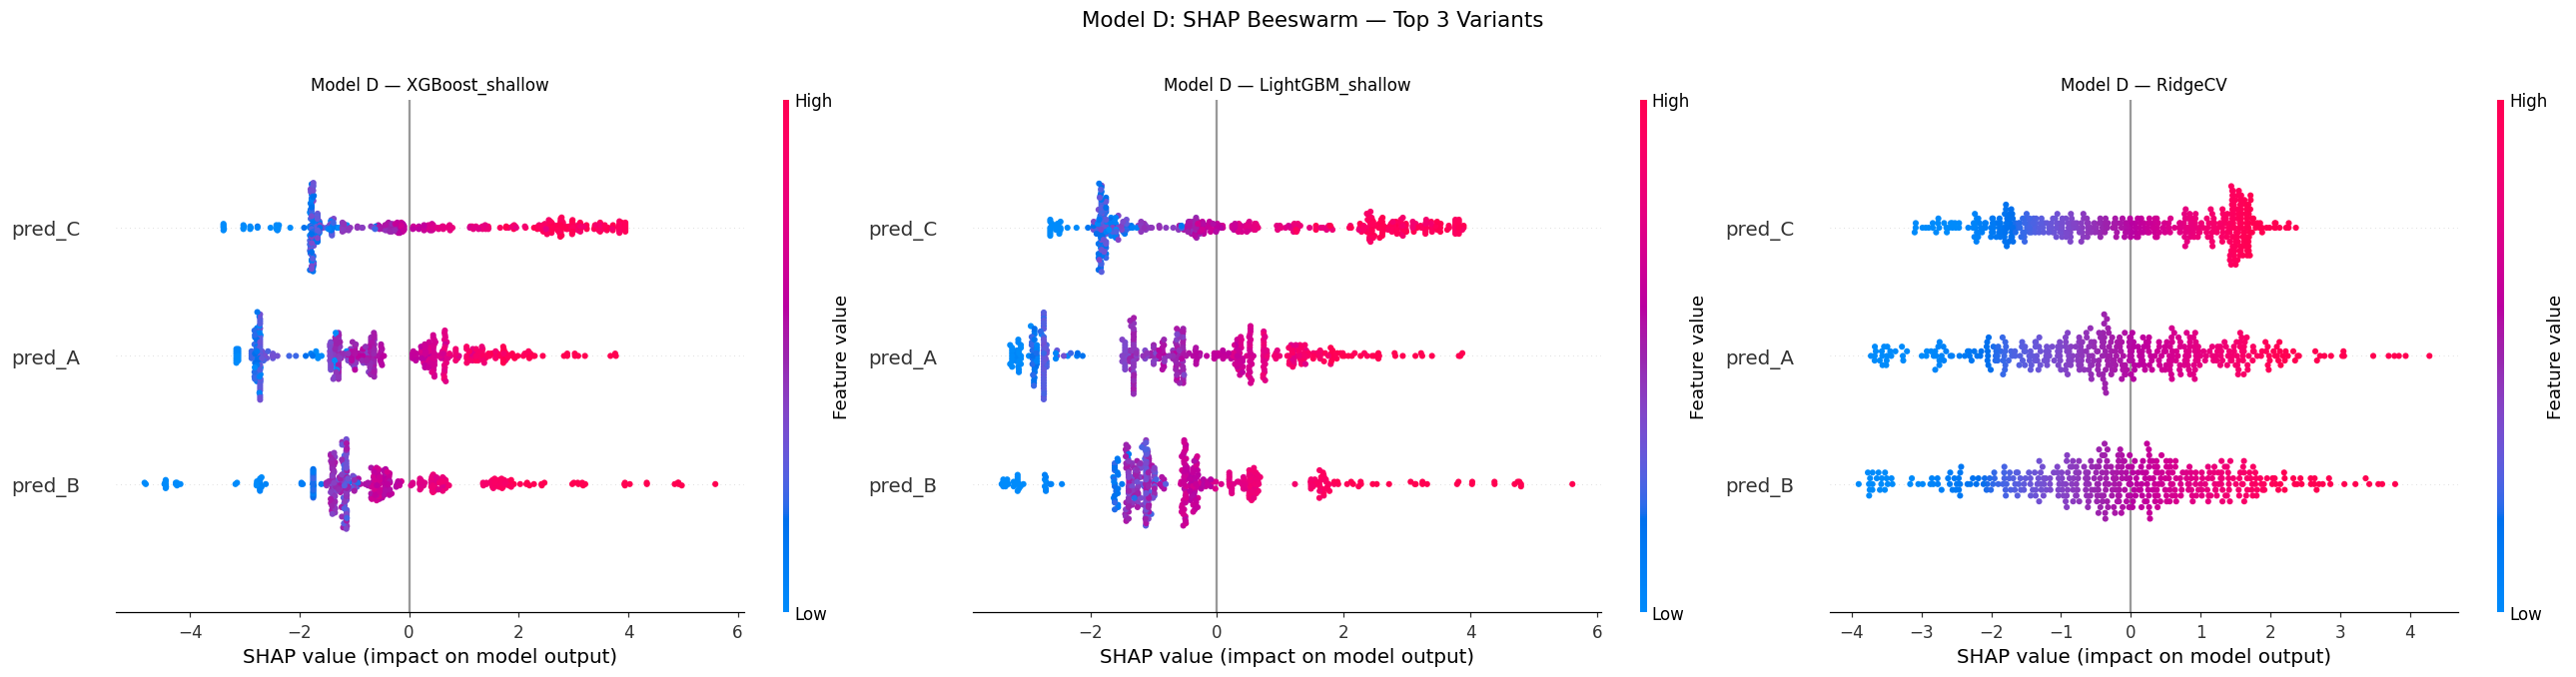

In [6]:
for model_type in ["A", "B", "C", "D"]:
    variants = TOP3[model_type]
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    for i, variant in enumerate(variants):
        key = (model_type, variant)
        sv = shap_results[key]["shap_values"]
        X_disp = shap_results[key]["X"]

        plt.sca(axes[i])
        shap.summary_plot(
            sv, X_disp,
            show=False,
            max_display=15,
            plot_size=None,
        )
        axes[i].set_title(f"Model {model_type} — {variant}", fontsize=11)

    fig.suptitle(
        f"Model {model_type}: SHAP Beeswarm — Top 3 Variants",
        fontsize=14, y=1.02,
    )
    plt.tight_layout()
    plt.show()

## 4. Mean |SHAP| Bar Charts

Global feature importance: average absolute SHAP contribution per feature.

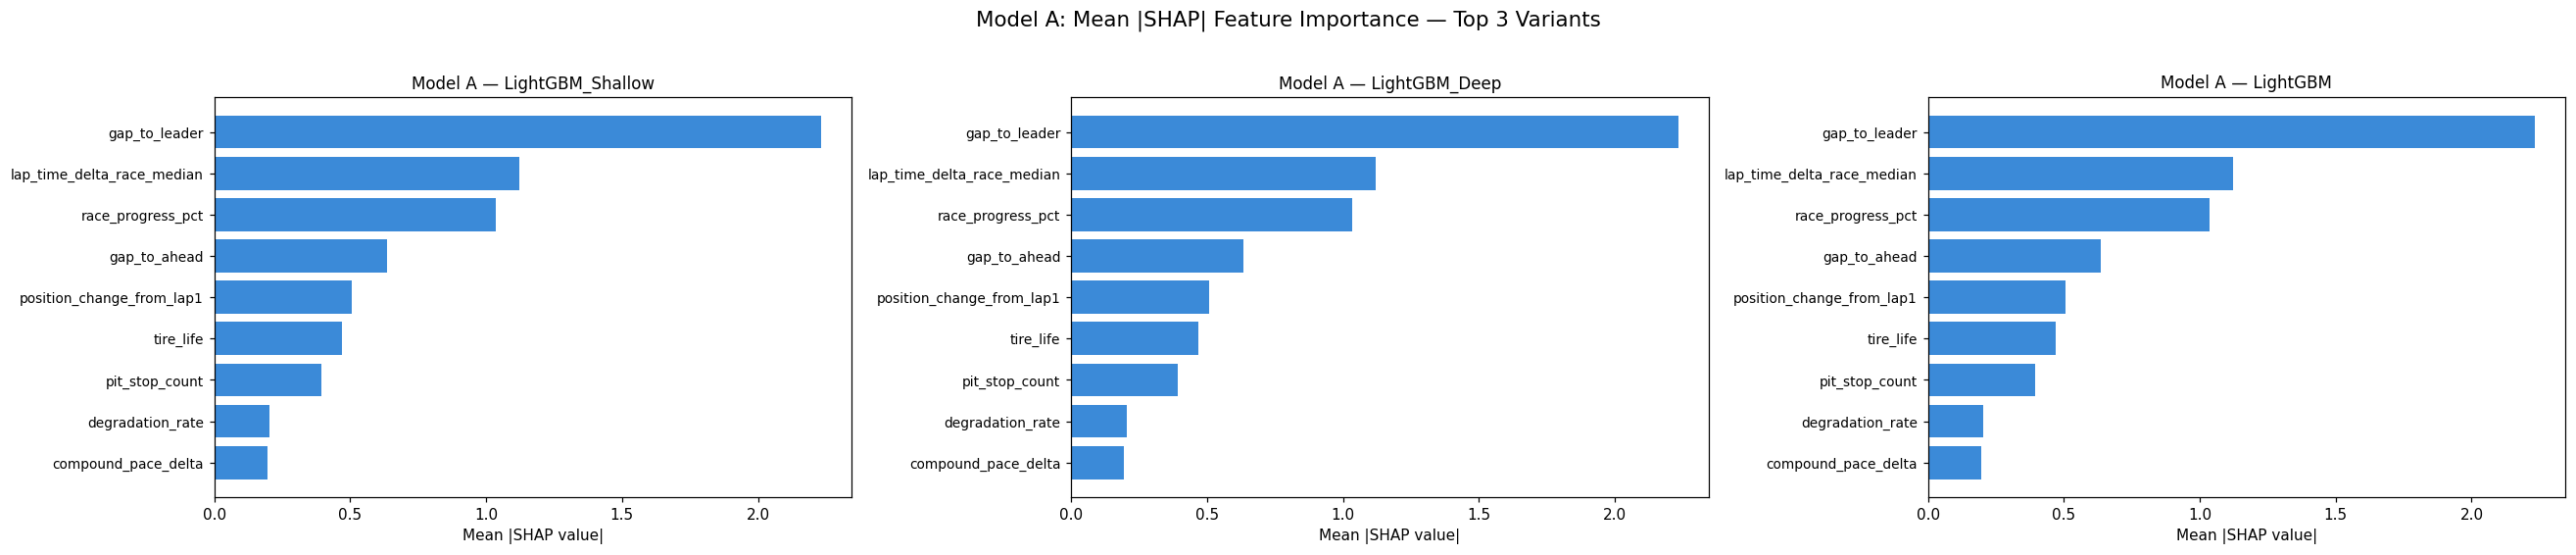

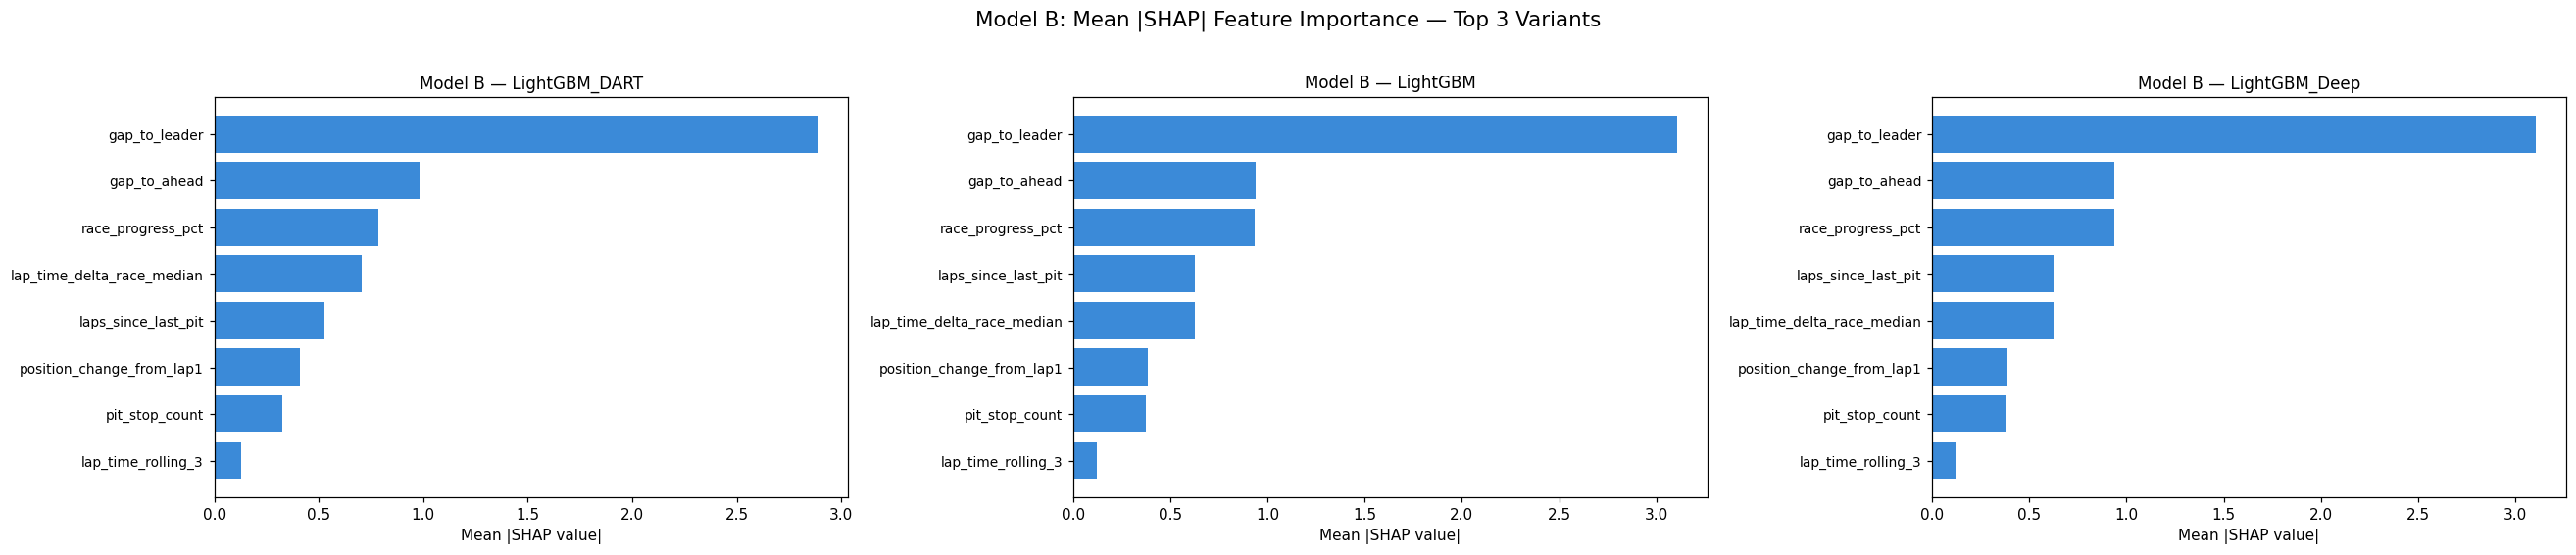

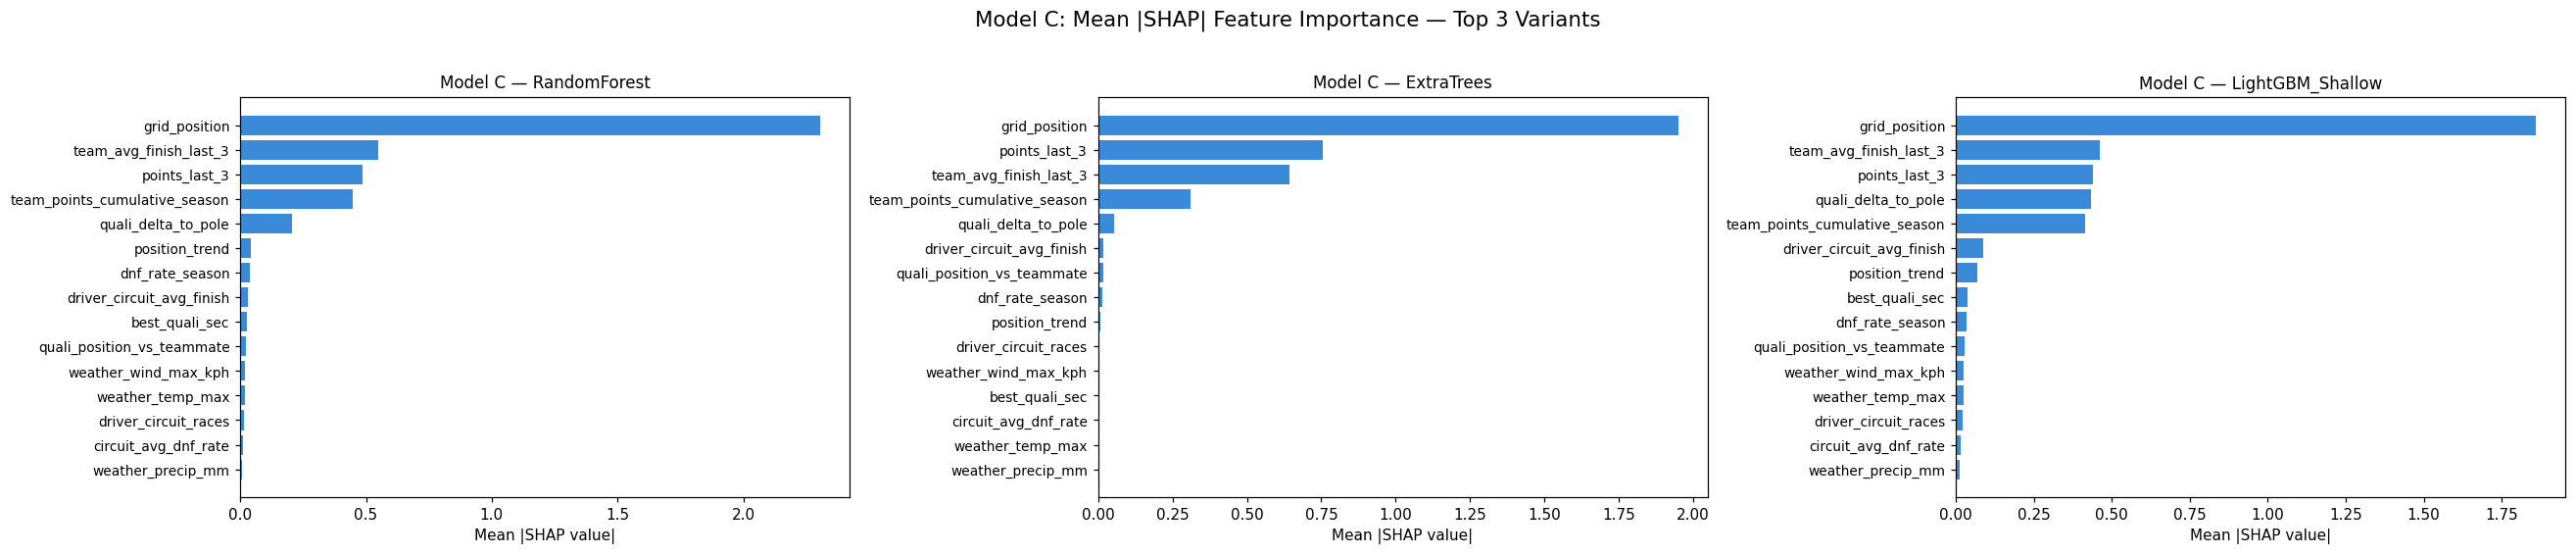

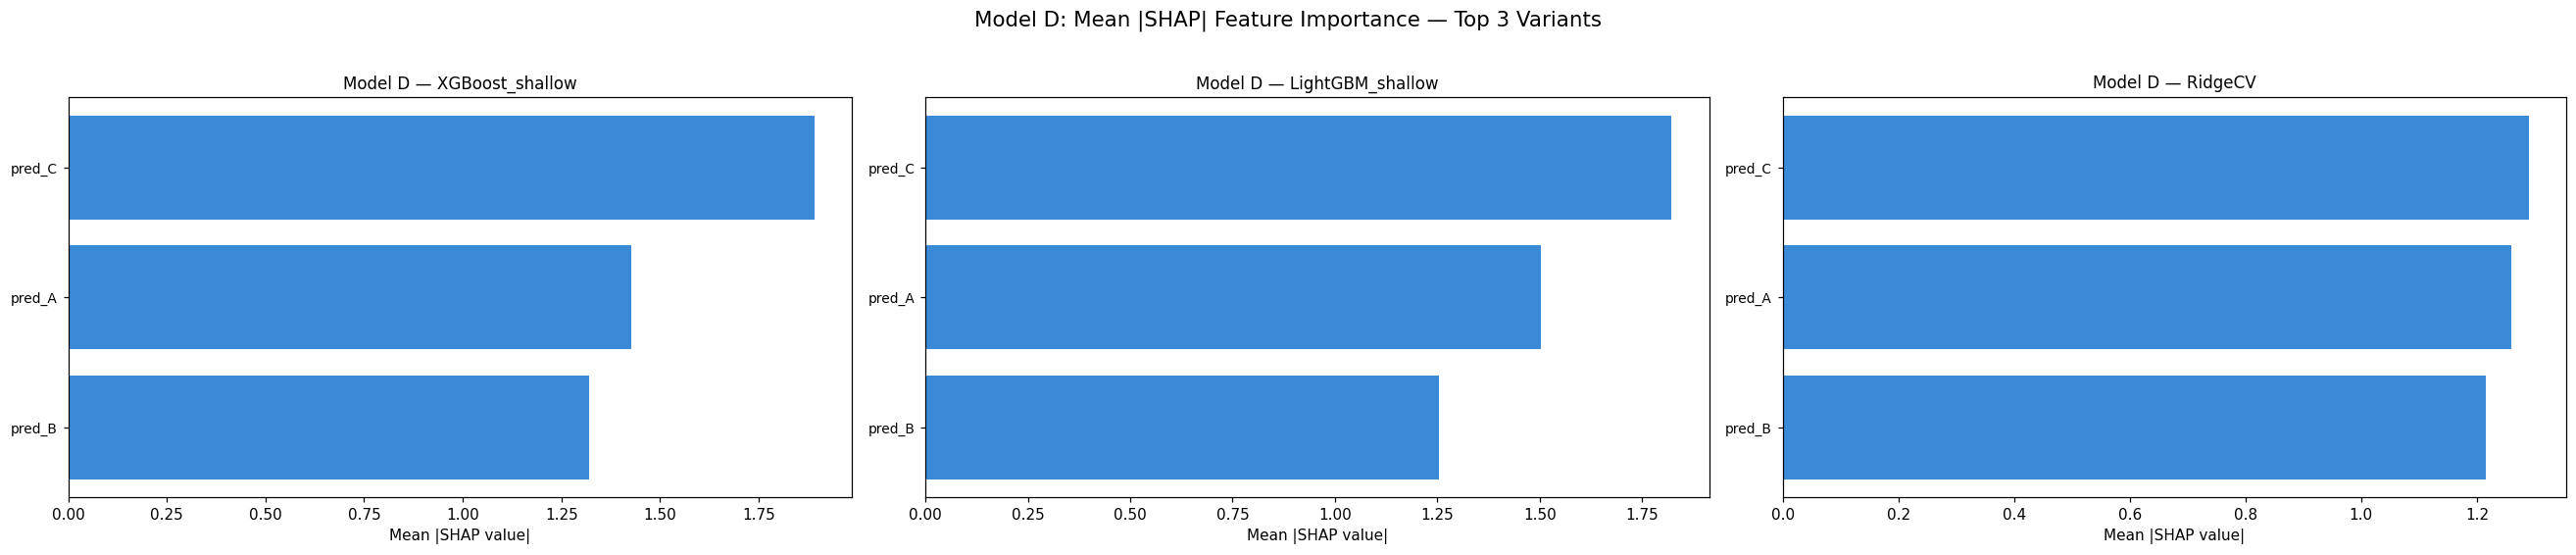

In [7]:
for model_type in ["A", "B", "C", "D"]:
    variants = TOP3[model_type]
    fig, axes = plt.subplots(1, 3, figsize=(24, 5))

    for i, variant in enumerate(variants):
        key = (model_type, variant)
        sv = shap_results[key]["shap_values"]
        feature_names = shap_results[key]["feature_names"]

        mean_abs = np.abs(sv).mean(axis=0)
        order = np.argsort(mean_abs)[::-1]

        axes[i].barh(
            range(len(order)),
            mean_abs[order],
            color="#1976D2",
            alpha=0.85,
        )
        axes[i].set_yticks(range(len(order)))
        axes[i].set_yticklabels([feature_names[j] for j in order], fontsize=9)
        axes[i].invert_yaxis()
        axes[i].set_xlabel("Mean |SHAP value|")
        axes[i].set_title(f"Model {model_type} — {variant}", fontsize=11)

    fig.suptitle(
        f"Model {model_type}: Mean |SHAP| Feature Importance — Top 3 Variants",
        fontsize=14, y=1.02,
    )
    plt.tight_layout()
    plt.show()

## 5. Feature Importance Consistency Across Variants

Do the top 3 variants of each model type agree on which features matter most?

In [8]:
for model_type in ["A", "B", "C", "D"]:
    variants = TOP3[model_type]
    feature_names = shap_results[(model_type, variants[0])]["feature_names"]

    rankings = {}
    for variant in variants:
        sv = shap_results[(model_type, variant)]["shap_values"]
        mean_abs = np.abs(sv).mean(axis=0)
        rank = np.argsort(np.argsort(-mean_abs)) + 1
        rankings[variant] = rank

    rank_df = pd.DataFrame(rankings, index=feature_names)
    rank_df["Mean Rank"] = rank_df.mean(axis=1)
    rank_df = rank_df.sort_values("Mean Rank")

    print(f"\nModel {model_type} — Feature Importance Ranking (1=most important):")
    print(rank_df.to_string())
    print()


Model A — Feature Importance Ranking (1=most important):
                            LightGBM_Shallow  LightGBM_Deep  LightGBM  Mean Rank
gap_to_leader                              1              1         1        1.0
lap_time_delta_race_median                 2              2         2        2.0
race_progress_pct                          3              3         3        3.0
gap_to_ahead                               4              4         4        4.0
position_change_from_lap1                  5              5         5        5.0
tire_life                                  6              6         6        6.0
pit_stop_count                             7              7         7        7.0
degradation_rate                           8              8         8        8.0
compound_pace_delta                        9              9         9        9.0


Model B — Feature Importance Ranking (1=most important):
                            LightGBM_DART  LightGBM  LightGBM_Deep  Mean 

## 6. SHAP Dependence Plots — Top 2 Features per Model

Shows how each feature's value relates to its SHAP contribution.
Color encodes the feature with the strongest interaction.

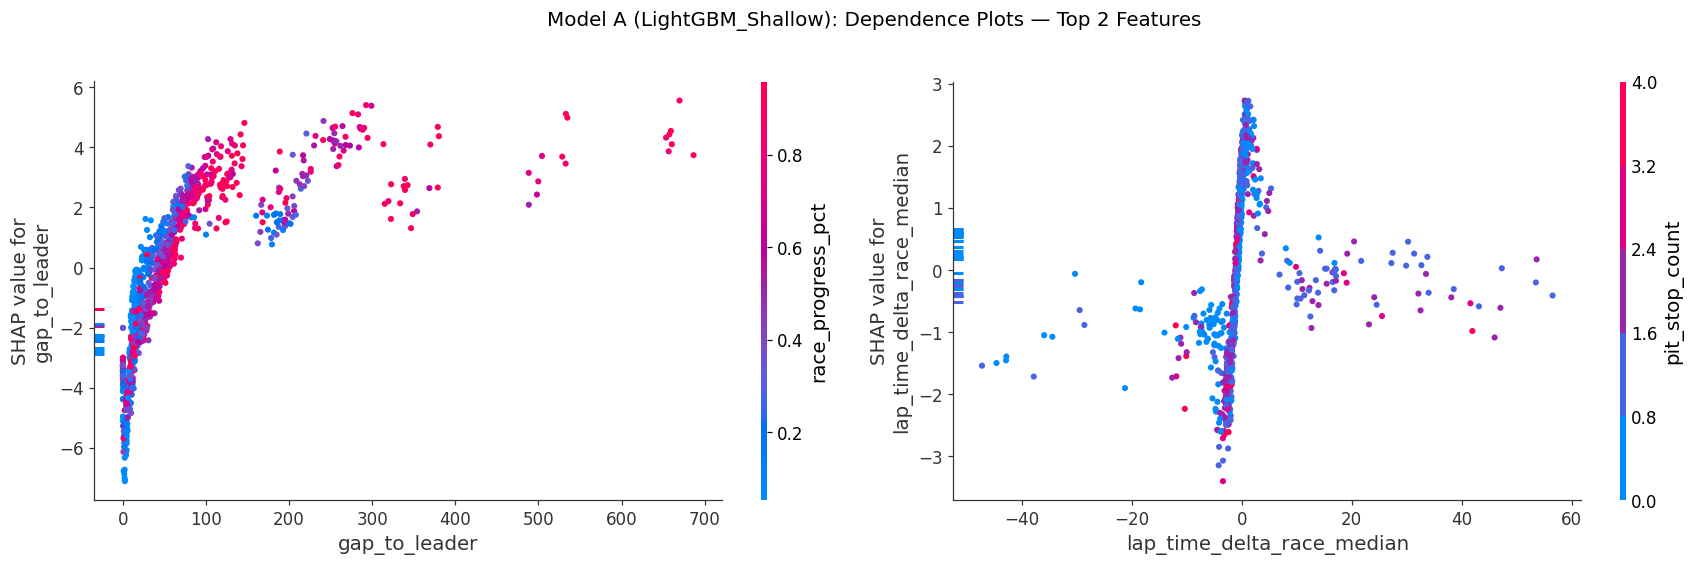

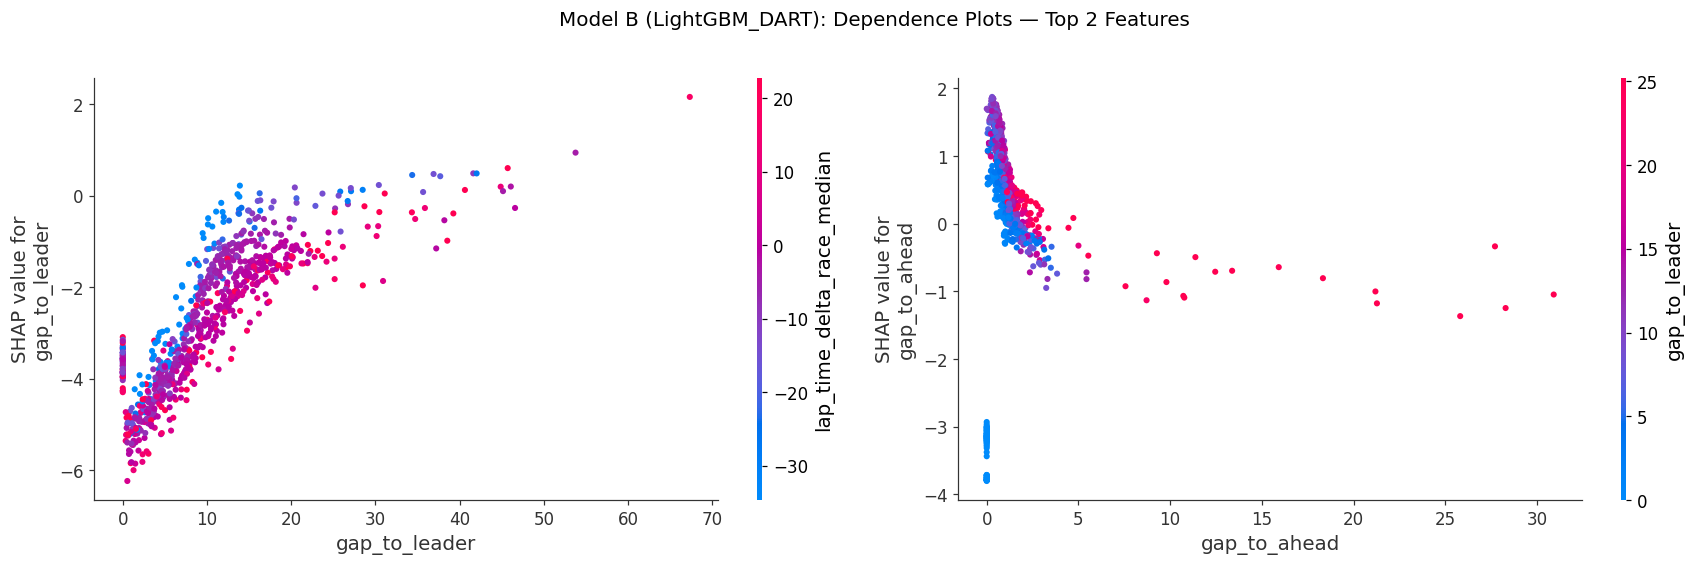

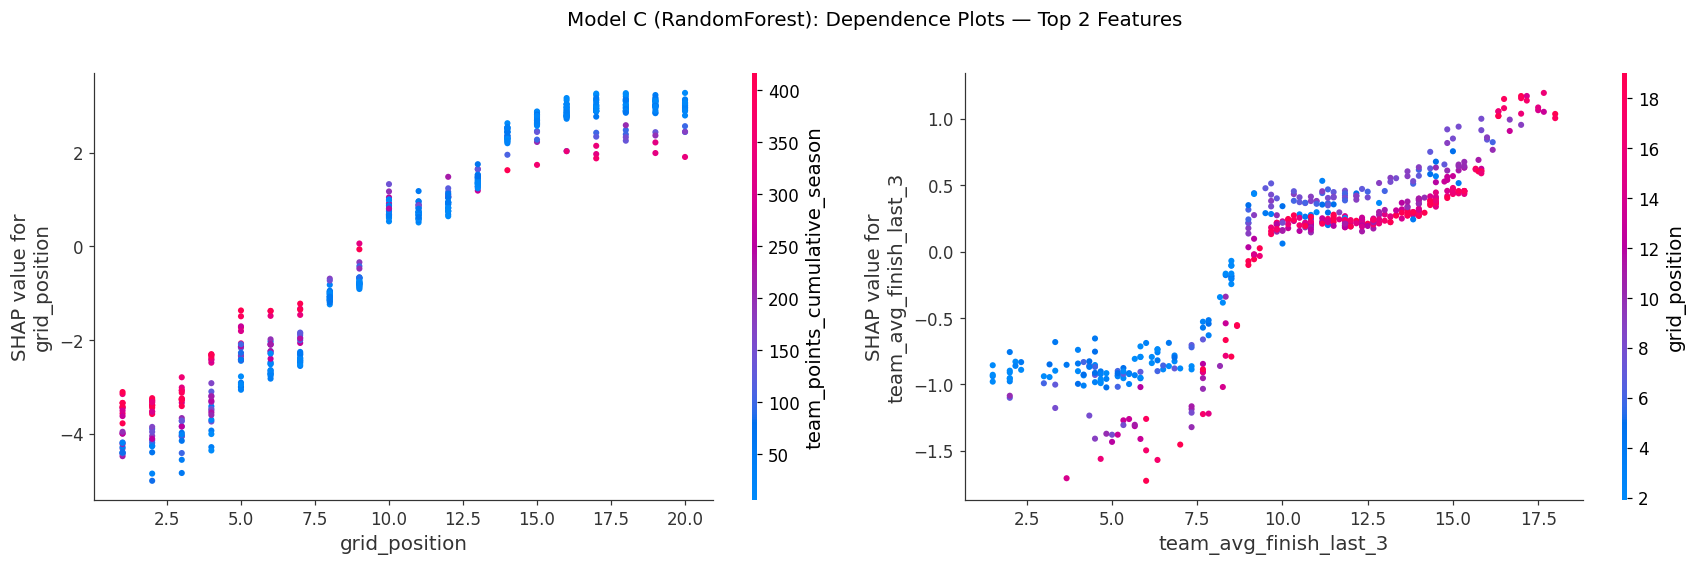

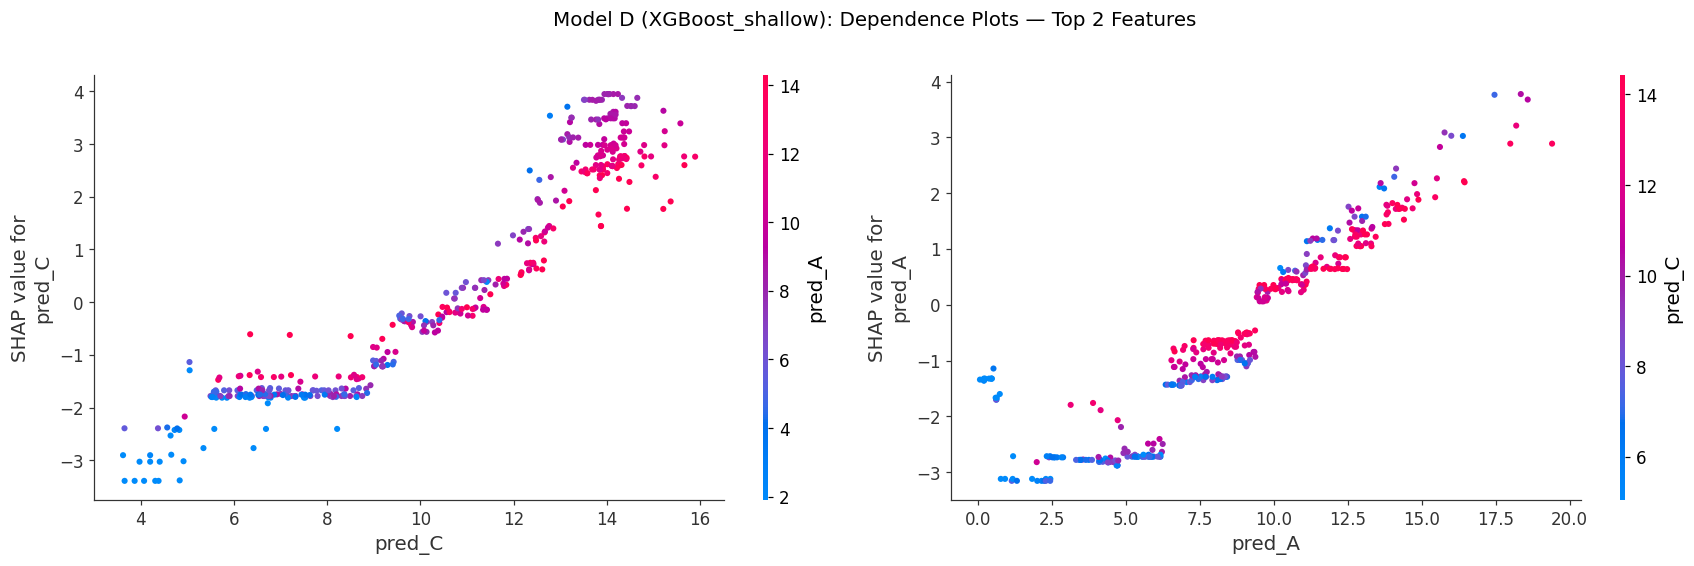

In [9]:
for model_type in ["A", "B", "C", "D"]:
    best_variant = TOP3[model_type][0]
    key = (model_type, best_variant)
    sv = shap_results[key]["shap_values"]
    X_disp = shap_results[key]["X"]
    feature_names = shap_results[key]["feature_names"]

    mean_abs = np.abs(sv).mean(axis=0)
    top2_idx = np.argsort(mean_abs)[-2:][::-1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for i, feat_idx in enumerate(top2_idx):
        plt.sca(axes[i])
        shap.dependence_plot(
            feat_idx, sv, X_disp,
            show=False,
            ax=axes[i],
        )
    fig.suptitle(
        f"Model {model_type} ({best_variant}): Dependence Plots — Top 2 Features",
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    plt.show()

## 7. SHAP Force Plot — Single Race Example

Visualize the SHAP decomposition for a single prediction from each model's best variant.

In [10]:
shap.initjs()

for model_type in ["A", "B", "C", "D"]:
    best_variant = TOP3[model_type][0]
    key = (model_type, best_variant)
    sv = shap_results[key]["shap_values"]
    X_disp = shap_results[key]["X"]

    model = load_model(model_type, best_variant)
    if hasattr(model, "named_steps"):
        base_value = model.predict(X_disp).mean()
    else:
        base_value = model.predict(X_disp.values).mean()

    sample_idx = 0
    print(f"\nModel {model_type} ({best_variant}) — Sample prediction:")
    print(f"  Base value: {base_value:.2f}")
    print(f"  SHAP sum:   {sv[sample_idx].sum():.2f}")
    print(f"  Prediction: {base_value + sv[sample_idx].sum():.2f}")

    display(shap.force_plot(
        base_value,
        sv[sample_idx],
        X_disp.iloc[sample_idx],
    ))


Model A (LightGBM_Shallow) — Sample prediction:
  Base value: 9.33
  SHAP sum:   1.35
  Prediction: 10.69



Model B (LightGBM_DART) — Sample prediction:
  Base value: 6.21
  SHAP sum:   1.18
  Prediction: 7.40



Model C (RandomForest) — Sample prediction:
  Base value: 10.20
  SHAP sum:   -1.75
  Prediction: 8.46



Model D (XGBoost_shallow) — Sample prediction:
  Base value: 9.81
  SHAP sum:   3.02
  Prediction: 12.82


## 8. Cross-Model Feature Importance Comparison

Which features matter across multiple model types? This uses the shared features between
Models A and B (both lap-level), and shows Model C and D features separately.

Features shared between Model A and B: ['gap_to_ahead', 'gap_to_leader', 'lap_time_delta_race_median', 'pit_stop_count', 'position_change_from_lap1', 'race_progress_pct']



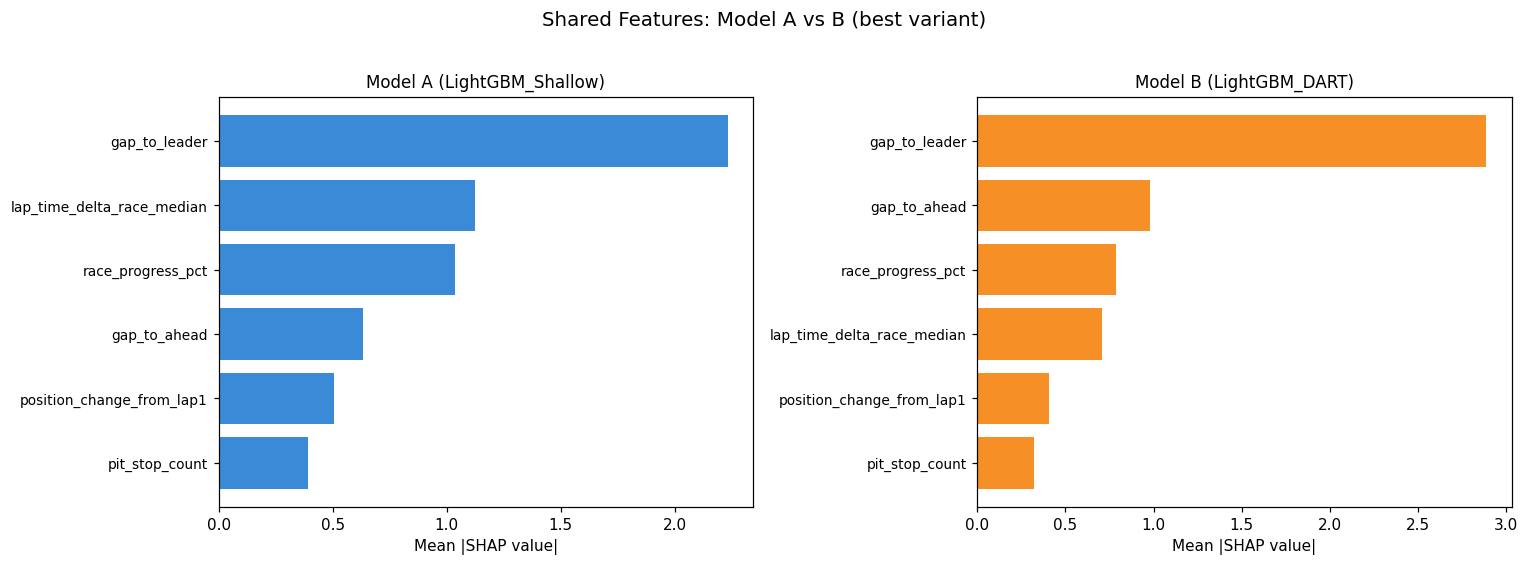

In [11]:
shared_ab = sorted(set(FEATURE_COLS["A"]) & set(FEATURE_COLS["B"]))
print(f"Features shared between Model A and B: {shared_ab}\n")

if shared_ab:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for i, model_type in enumerate(["A", "B"]):
        best_variant = TOP3[model_type][0]
        key = (model_type, best_variant)
        sv = shap_results[key]["shap_values"]
        feature_names = shap_results[key]["feature_names"]

        shared_idx = [feature_names.index(f) for f in shared_ab if f in feature_names]
        shared_sv = sv[:, shared_idx]
        mean_abs = np.abs(shared_sv).mean(axis=0)
        order = np.argsort(mean_abs)[::-1]

        axes[i].barh(
            range(len(order)),
            mean_abs[order],
            color="#F57C00" if model_type == "B" else "#1976D2",
            alpha=0.85,
        )
        axes[i].set_yticks(range(len(order)))
        axes[i].set_yticklabels([shared_ab[j] for j in order], fontsize=9)
        axes[i].invert_yaxis()
        axes[i].set_xlabel("Mean |SHAP value|")
        axes[i].set_title(f"Model {model_type} ({best_variant})", fontsize=11)

    fig.suptitle(
        "Shared Features: Model A vs B (best variant)",
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    plt.show()

## 9. Summary Table

Top 3 most important features per model type (by mean |SHAP|).

In [12]:
summary_rows = []
for model_type in ["A", "B", "C", "D"]:
    best_variant = TOP3[model_type][0]
    key = (model_type, best_variant)
    sv = shap_results[key]["shap_values"]
    feature_names = shap_results[key]["feature_names"]

    mean_abs = np.abs(sv).mean(axis=0)
    top3_idx = np.argsort(mean_abs)[-3:][::-1]

    for rank, idx in enumerate(top3_idx, 1):
        summary_rows.append({
            "Model": model_type,
            "Variant": best_variant,
            "Rank": rank,
            "Feature": feature_names[idx],
            "Mean |SHAP|": mean_abs[idx],
        })

summary_df = pd.DataFrame(summary_rows)
print("Top 3 Features per Model (by Mean |SHAP|):\n")
print(summary_df.to_string(index=False))

print("\n" + "="*60)
print("SHAP analysis complete.")
print("Key insight: Compare feature rankings across model types to")
print("understand which signals are robust vs. model-specific.")

Top 3 Features per Model (by Mean |SHAP|):

Model          Variant  Rank                    Feature  Mean |SHAP|
    A LightGBM_Shallow     1              gap_to_leader     2.232190
    A LightGBM_Shallow     2 lap_time_delta_race_median     1.122286
    A LightGBM_Shallow     3          race_progress_pct     1.034320
    B    LightGBM_DART     1              gap_to_leader     2.889286
    B    LightGBM_DART     2               gap_to_ahead     0.981607
    B    LightGBM_DART     3          race_progress_pct     0.785126
    C     RandomForest     1              grid_position     2.307301
    C     RandomForest     2     team_avg_finish_last_3     0.547583
    C     RandomForest     3              points_last_3     0.486584
    D  XGBoost_shallow     1                     pred_C     1.891451
    D  XGBoost_shallow     2                     pred_A     1.425908
    D  XGBoost_shallow     3                     pred_B     1.320394

SHAP analysis complete.
Key insight: Compare feature ranki